In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

import scipy.io.wavfile as wavfile
import scipy.signal as signal
import sounddevice

def getSamples(tList, fct):
    return [fct(t) for t in tList]

def getSamples1(tList, f, fct):
    return [fct(t, f) for t in tList]

def getSamples2(tList, f, a, fct):
    return [fct(t, a, f) for t in tList]

def getSamples3(tList, f, a, phi, fct):
    return [fct(t, a, f, phi) for t in tList]

def plot(timeAxis, fct):
    plt.stem(timeAxis, getSamples(timeAxis, fct))
    
def plot1(timeAxis, f, fct):
    plt.stem(timeAxis, getSamples1(timeAxis, f, fct))

def plot2(timeAxis, f, a, fct):
    plt.stem(timeAxis, getSamples2(timeAxis, f, a, fct))

def plot3(timeAxis, f, a, phi, fct):
    plt.stem(timeAxis, getSamples3(timeAxis, f, a, phi, fct))
    

In [109]:
def semnalSin(t, f, a, phi):
    return a*np.sin(2*np.pi*f*t + phi)

def semnalCos(t, f, a, phi):
    return a*np.cos(2*np.pi*f*t + phi)

def semnalSawtooth(t, f, a, phi):
    return a*np.mod(2*f*np.pi*t + phi, 2*np.pi)

def semnalSquare(t, f, a, phi):
    return np.sign(semnalSin(t, f, a, phi))

def semnalIdentity(t):
    return t


In [3]:
discreteTimeAxis = np.linspace(0, 2, 1600)


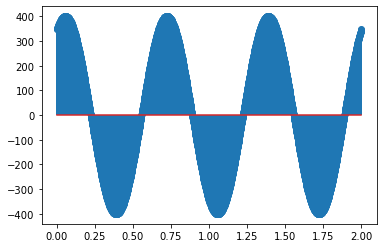

In [4]:
# ex 1
plot3(discreteTimeAxis, 400, 1.5, np.pi/3, semnalSin)



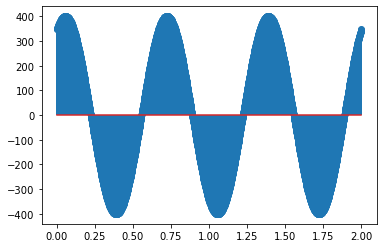

In [5]:
plot3(discreteTimeAxis, 400, 1.5, np.pi*(1/3-1/2), semnalCos)


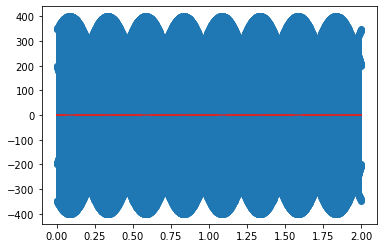

In [6]:
# ex 2
plot3(discreteTimeAxis, 400, 1, np.pi*(1/3), semnalSin)
plot3(discreteTimeAxis, 400, 1, np.pi*(1/3+1/2), semnalSin)
plot3(discreteTimeAxis, 400, 1, np.pi*(1/3+1), semnalSin)
plot3(discreteTimeAxis, 400, 1, np.pi*(1/3-1/2), semnalSin)


In [7]:
# ex 3
# ----------------
# ex 2 (lab1)
# a

discreteTimeAxis2a = np.linspace(0, 3, 1600)
l
F2a = 400

semnal2a = getSamples3(discreteTimeAxis2a, F2a, 1, np.pi/3, semnalSin)

# b

discreteTimeAxis2b = np.linspace(0, 3, 1600)

F2b = 800

semnal2b = getSamples3(discreteTimeAxis2b, F2b, 1, np.pi/3, semnalSin)

# c

discreteTimeAxis2c = np.linspace(0, 3, 1600)
F2c = 240

semnal2c = getSamples3(discreteTimeAxis2c, F2c, 1, np.pi/3, semnalSawtooth)

# d

discreteTimeAxis2d = np.linspace(0, 3, 1600)
F2d = 300

semnal2d = getSamples3(discreteTimeAxis2d, F2d, 1, np.pi/3, semnalSquare)


<StemContainer object of 3 artists>

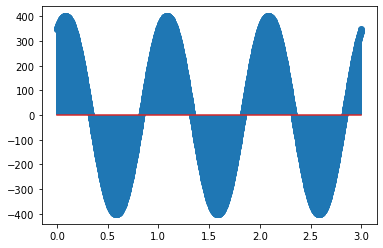

In [8]:
plt.stem(discreteTimeAxis2a, semnal2a)


<StemContainer object of 3 artists>

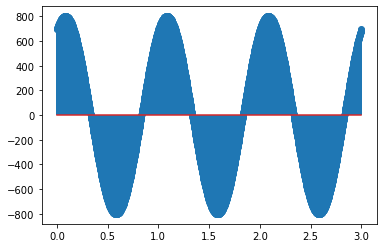

In [9]:
plt.stem(discreteTimeAxis2b, semnal2b)


<StemContainer object of 3 artists>

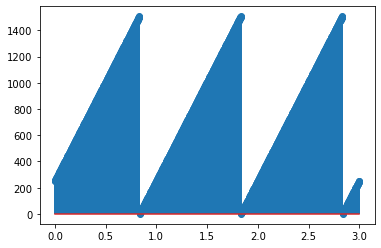

In [10]:
plt.stem(discreteTimeAxis2c, semnal2c)


<StemContainer object of 3 artists>

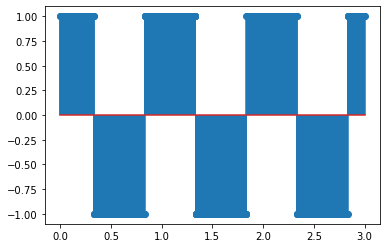

In [11]:
plt.stem(discreteTimeAxis2d, semnal2d)


In [16]:
rate = int(10e5)

wavfile.write('semnal2a.wav', rate, np.asarray(semnal2a))
wavfile.write('semnal2b.wav', rate, np.asarray(semnal2b))
wavfile.write('semnal2c.wav', rate, np.asarray(semnal2c))
wavfile.write('semnal2d.wav', rate, np.asarray(semnal2d))


In [32]:
def play(path):
    rate, semnal = wavfile.read(path)
    
    fs = 44100
    sounddevice.play(semnal, fs)
    

In [33]:
play('semnal2a.wav')

In [31]:
play('semnal2b.wav')

In [24]:
play('semnal2c.wav')

In [25]:
play('semnal2d.wav')

In [45]:
minLen = min([len(semnal2b), len(semnal2c)])

discreteTimeAxis2bc = [0] * minLen
semnal2bc = [0] * minLen
for i in range(minLen):
    discreteTimeAxis2bc[i] = discreteTimeAxis2b[i] + discreteTimeAxis2c[i]
    semnal2bc[i] = semnal2b[i] + semnal2c[i]
    

<StemContainer object of 3 artists>

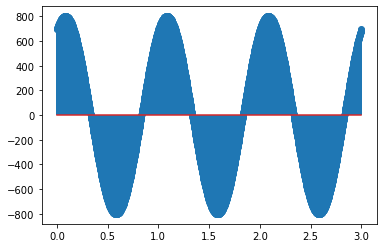

In [47]:
plt.stem(discreteTimeAxis2b, semnal2b)


<StemContainer object of 3 artists>

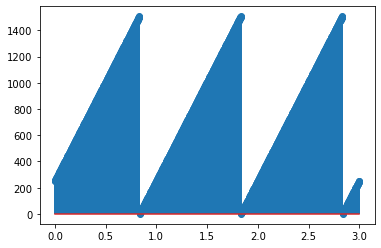

In [48]:
plt.stem(discreteTimeAxis2c, semnal2c)


<StemContainer object of 3 artists>

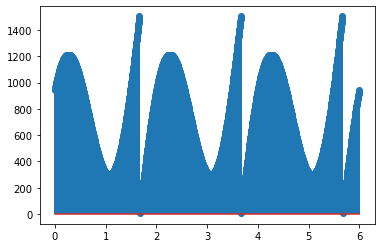

In [49]:
plt.stem(discreteTimeAxis2bc, semnal2bc)


In [70]:
# ex 5
discreteTimeAxis2ab = np.linspace(0,6,3200)
semnal2ab = semnal2a + semnal2b

print(len(semnal2a))
print(len(semnal2b))
print(len(semnal2ab))
print(len(discreteTimeAxis2a))
print(len(discreteTimeAxis2b))
print(len(discreteTimeAxis2ab))


1600
1600
3200
1600
1600
3200


<StemContainer object of 3 artists>

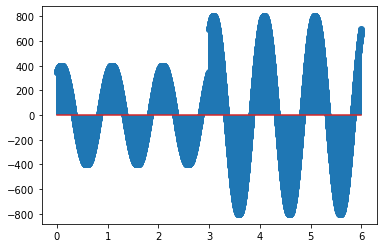

In [71]:
plt.stem(discreteTimeAxis2ab, semnal2ab)

In [72]:
wavfile.write('semnal2bc.wav', rate, np.asarray(semnal2bc))
wavfile.write('semnal2ab.wav', rate, np.asarray(semnal2ab))


In [77]:
play('semnal2bc.wav')


In [78]:
play('semnal2ab.wav')

# suna mai distorsionat / cu zgomot

In [80]:
# ex 6
discreteTimeAxis6 = np.linspace(0, 10, 5000) 
# fs (frecventa esantionare) = 500 samples/secunda

semnal6a = getSamples3(discreteTimeAxis6, 250, 1, 0, semnalSin)
semnal6b = getSamples3(discreteTimeAxis6, 125, 1, 0, semnalSin)
semnal6c = getSamples3(discreteTimeAxis6, 0, 1, 0, semnalSin)


In [81]:
wavfile.write('semnal6a.wav', rate, np.asarray(semnal6a))
wavfile.write('semnal6b.wav', rate, np.asarray(semnal6b))
wavfile.write('semnal6c.wav', rate, np.asarray(semnal6c))


In [86]:
play('semnal6a.wav') # destul de grav

In [87]:
play('semnal6b.wav') # mai grav

In [85]:
play('semnal6c.wav') # nu se mai aude nimic

In [103]:
# ex 7
discreteTimeAxis7 = np.linspace(0, 1, 500) 

semnal7a = getSamples3(discreteTimeAxis7, 1000, 1, 0, semnalSin)
semnal7b = [0]*len(semnal7a)
semnal7c = [0]*len(semnal7a)

for i in range(len(semnal7a)):
    if i % 4 != 3:
        semnal7b[i] = 0
    else:
        semnal7b[i] = semnal7a[i]
    if i % 4 != 0:
        semnal7c[i] = 0
    else:
        semnal7c[i] = semnal7a[i]
        

<StemContainer object of 3 artists>

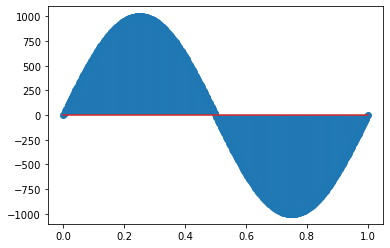

In [100]:
plt.stem(discreteTimeAxis7, semnal7a)


<StemContainer object of 3 artists>

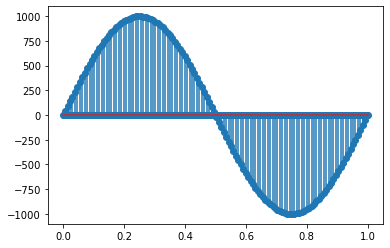

In [102]:
plt.stem(discreteTimeAxis7, semnal7b)
# semnalul are intreruperi mai mari, ca si cand ar avea frecventa de esantionare mai mica


<StemContainer object of 3 artists>

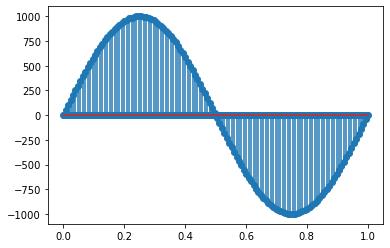

In [104]:
plt.stem(discreteTimeAxis7, semnal7c)
# intreruperile au fost si ele shiftate la dreapta


In [128]:
# ex 8
discreteTimeAxis8 = np.linspace(-np.pi/2, np.pi/2, 500)


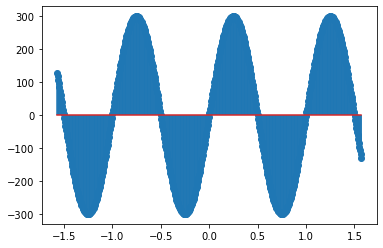

In [129]:
plot3(discreteTimeAxis8, 300, 1, 0, semnalSin)


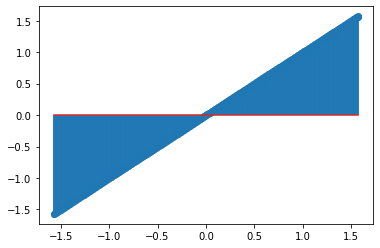

In [130]:
plot(discreteTimeAxis8, semnalIdentity)